In [1]:
%pip install -q -e ../01_generate-seq-and-emb

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from idr.utils import get_device, iter_models

print('✅ imports loaded')

Note: you may need to restart the kernel to use updated packages.


/Users/leeminjae/micromamba/envs/dna-fm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ imports loaded


In [2]:
DATA_DIR = Path('../data')
EVO_PHAGE_CSV = DATA_DIR / 'evo-phage-seq.csv'
EVO_PHAGE_EMB_DIR = DATA_DIR / 'embeddings' / 'evo-phage'
PROMOTER_EMB_DIR = DATA_DIR / 'embeddings' / 'promoters'
PROMOTER_DATA_DIR = DATA_DIR / 'promoters'

GENE = 'GAPDH'
MODELS = ['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m']
model_configs = {
    'DNABERT-2': 'zhihan1996/DNABERT-2-117M',
    'NT-v2-50m': 'InstaDeepAI/nucleotide-transformer-v2-50m-multi-species',
    'NT-v2-500m': 'InstaDeepAI/nucleotide-transformer-v2-500m-multi-species',
}
RUN_TAGS = [
    'sampling_t1.0_mask0.1_iter30',
    'sampling_t1.0_mask0.2_iter30',
]
RUN_TAG_LABELS = {
    'sampling_t1.0_mask0.1_iter30': 'mask=0.1',
    'sampling_t1.0_mask0.2_iter30': 'mask=0.2',
}
torch_dtype = 'float32'

PROMOTER_EMB_DIR.mkdir(parents=True, exist_ok=True)

print(f'Models: {MODELS}')
print(f'Run tags: {RUN_TAGS}')

Models: ['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m']
Run tags: ['sampling_t1.0_mask0.1_iter30', 'sampling_t1.0_mask0.2_iter30']


## 1. evo-phage: similarity to original phiX174

In [3]:
evo_df = pd.read_csv(EVO_PHAGE_CSV)
print(f'evo-phage sequences: {len(evo_df)} rows')
print(evo_df['genome'].tolist())

evo-phage sequences: 19 rows
['original', 'Evo-Φ4', 'Evo-Φ5', 'Evo-Φ36', 'Evo-Φ46', 'Evo-Φ63', 'Evo-Φ69', 'Evo-Φ75', 'Evo-Φ100', 'Evo-Φ108', 'Evo-Φ111', 'Evo-Φ114', 'Evo-Φ316', 'Evo-Φ2147', 'Evo-Φ2483', 'Evo-Φ2498', 'Evo-Φ3392', 'Evo-ΦR1', 'Evo-ΦR2']


In [4]:
def cosine_similarity_1d(a, b):
    """Cosine similarity between two vectors (any shape: 1-D or 2-D with leading 1)."""
    a = np.asarray(a).flatten()
    b = np.asarray(b).flatten()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))


# evo-phage similarity: each variant vs 'original', per model
# evo_sims[model] = pd.Series(index=variant_genome, values=cosine_sim)
evo_sims = {}

for model in MODELS:
    npz_path = EVO_PHAGE_EMB_DIR / f'embeddings_{model}.npz'
    if not npz_path.exists():
        print(f'⚠️  Missing: {npz_path}')
        continue

    data = np.load(npz_path, allow_pickle=True)
    genomes = list(data['genomes'])
    embeddings = data['embeddings']  # (19, D)

    orig_idx = genomes.index('original')
    orig_emb = embeddings[orig_idx]

    sims = {}
    for i, genome in enumerate(genomes):
        if genome == 'original':
            continue
        sims[genome] = cosine_similarity_1d(orig_emb, embeddings[i])

    evo_sims[model] = pd.Series(sims)
    print(f'[{model}] evo-phage similarity range: {evo_sims[model].min():.4f} ~ {evo_sims[model].max():.4f}')


[DNABERT-2] evo-phage similarity range: 0.9936 ~ 0.9992
[NT-v2-50m] evo-phage similarity range: 0.9945 ~ 0.9998
[NT-v2-500m] evo-phage similarity range: 0.9840 ~ 0.9991


## 2. Promoter embeddings (generate & save)

In [5]:
def load_promoter_sequences(model, run_tag, gene=GENE):
    """Load all 31 iteration sequences for a given model and run_tag.
    Returns list of sequences [iter_00, iter_01, ..., iter_30].
    """
    csv_path = PROMOTER_DATA_DIR / run_tag / model / f'{gene}_promoter.csv'
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing promoter CSV: {csv_path}')
    df = pd.read_csv(csv_path, index_col=0)
    # Row: 'sampling_t1.0', Cols: iter_00 ~ iter_30
    row = df.iloc[0]
    return [row[f'iter_{i:02d}'] for i in range(df.shape[1])]


device = get_device()
print(f'디바이스: {device}')

# Generate promoter embeddings for each model (load each model once)
for model_label, model_instance in iter_models(device, model_configs, torch_dtype=torch_dtype):
    print(f'\n모델: {model_label}')

    for run_tag in RUN_TAGS:
        out_dir = PROMOTER_EMB_DIR / run_tag
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f'embeddings_{model_label}.npz'

        if out_path.exists():
            print(f'  ✅ Skip (already exists): {out_path}')
            continue

        seqs = load_promoter_sequences(model_label, run_tag)
        print(f'  [{run_tag}] Embedding {len(seqs)} sequences...')

        embs = []
        for seq in seqs:
            emb = model_instance.get_embedding(seq)  # (D,)
            embs.append(emb)
            gc.collect()

        embs_arr = np.stack(embs).astype(np.float32)  # (31, D)
        iterations = np.arange(len(seqs))

        np.savez_compressed(out_path, iterations=iterations, embeddings=embs_arr)
        print(f'  ✅ 저장: {out_path}  shape={embs_arr.shape}')

        del embs, embs_arr
        gc.collect()
        if device == 'cuda':
            import torch; torch.cuda.empty_cache()
        elif device == 'mps':
            import torch; torch.mps.empty_cache()

PyTorch Version: 2.6.0
Using device: mps
디바이스: mps
📥 Downloading DNABERT-2...


Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 136400.13it/s]
/Users/leeminjae/.cache/huggingface/modules/transformers_modules/_7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


✅ DNABERT-2 Triton patch applied successfully.
[DNABERT-2] Loading model...
[DNABERT-2] Model loaded successfully.
✅ DNABERT-2 loaded successfully.

모델: DNABERT-2
  ✅ Skip (already exists): ../data/embeddings/promoters/sampling_t1.0_mask0.1_iter30/embeddings_DNABERT-2.npz
  ✅ Skip (already exists): ../data/embeddings/promoters/sampling_t1.0_mask0.2_iter30/embeddings_DNABERT-2.npz
[NT-v2-50m] Loading model...
[NT-v2-50m] Model loaded successfully.
✅ NT-v2-50m loaded successfully.

모델: NT-v2-50m
  ✅ Skip (already exists): ../data/embeddings/promoters/sampling_t1.0_mask0.1_iter30/embeddings_NT-v2-50m.npz
  ✅ Skip (already exists): ../data/embeddings/promoters/sampling_t1.0_mask0.2_iter30/embeddings_NT-v2-50m.npz
[NT-v2-500m] Loading model...
[NT-v2-500m] Model loaded successfully.
✅ NT-v2-500m loaded successfully.

모델: NT-v2-500m
  ✅ Skip (already exists): ../data/embeddings/promoters/sampling_t1.0_mask0.1_iter30/embeddings_NT-v2-500m.npz
  ✅ Skip (already exists): ../data/embeddings/prom

## 3. Promoter similarity over iterations (vs iter_00)

In [6]:
# promoter_sims[(model, run_tag)] = np.array of shape (31,)
# index 0 is self-similarity (should be ~1.0)
promoter_sims = {}

for model in MODELS:
    for run_tag in RUN_TAGS:
        npz_path = PROMOTER_EMB_DIR / run_tag / f'embeddings_{model}.npz'
        if not npz_path.exists():
            print(f'⚠️  Missing: {npz_path}')
            continue

        data = np.load(npz_path, allow_pickle=True)
        embs = data['embeddings']  # (31, D)
        orig_emb = embs[0]         # iter_00 is the reference

        sims = np.array([cosine_similarity_1d(orig_emb, embs[i]) for i in range(len(embs))])
        promoter_sims[(model, run_tag)] = sims

        print(f'[{model}] {run_tag}: iter_00 sim={sims[0]:.4f}, iter_30 sim={sims[-1]:.4f}')

[DNABERT-2] sampling_t1.0_mask0.1_iter30: iter_00 sim=1.0000, iter_30 sim=0.9088
[DNABERT-2] sampling_t1.0_mask0.2_iter30: iter_00 sim=1.0000, iter_30 sim=0.8391
[NT-v2-50m] sampling_t1.0_mask0.1_iter30: iter_00 sim=1.0000, iter_30 sim=0.9722
[NT-v2-50m] sampling_t1.0_mask0.2_iter30: iter_00 sim=1.0000, iter_30 sim=0.9654
[NT-v2-500m] sampling_t1.0_mask0.1_iter30: iter_00 sim=1.0000, iter_30 sim=0.9566
[NT-v2-500m] sampling_t1.0_mask0.2_iter30: iter_00 sim=1.0000, iter_30 sim=0.9171


## 4. Visualization

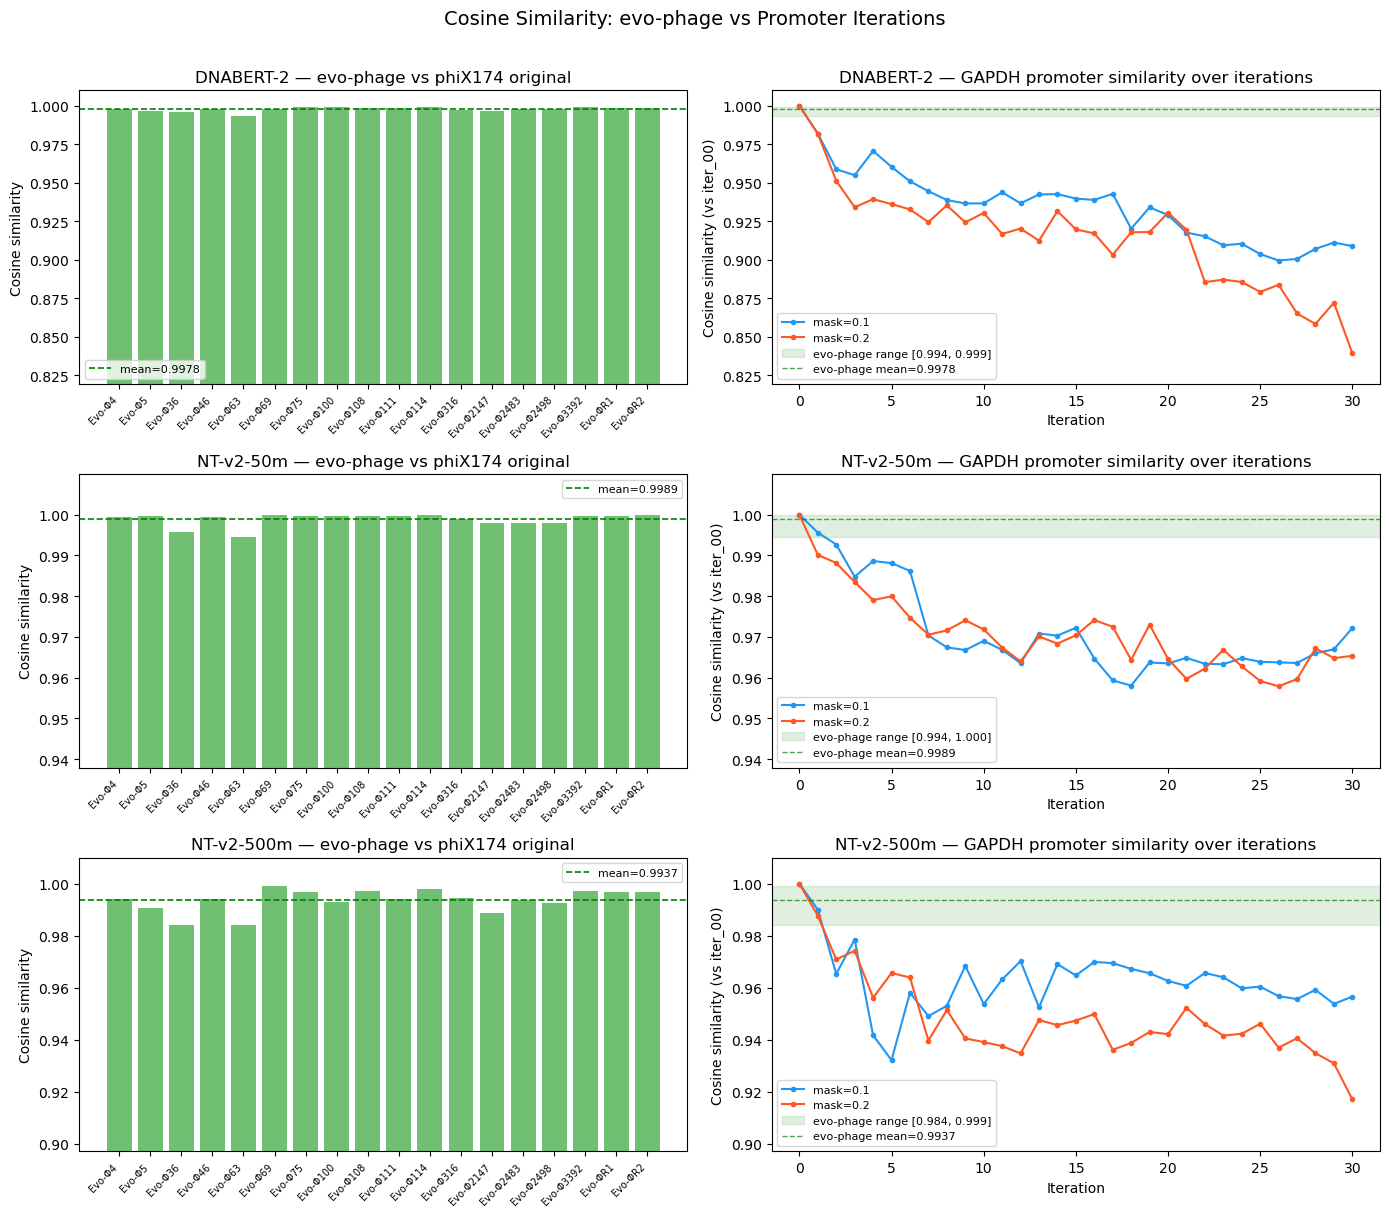

Figure saved: ../figures/promoter-evo-similarity.png


In [7]:
fig, axes = plt.subplots(len(MODELS), 2, figsize=(14, 4 * len(MODELS)))
fig.suptitle('Cosine Similarity: evo-phage vs Promoter Iterations', fontsize=14, y=1.01)

run_tag_colors = {
    'sampling_t1.0_mask0.1_iter30': '#2196F3',
    'sampling_t1.0_mask0.2_iter30': '#FF5722',
}

for row_idx, model in enumerate(MODELS):
    ax_evo = axes[row_idx, 0]
    ax_pro = axes[row_idx, 1]

    # ── Left: evo-phage bar chart ────────────────────────────────
    if model in evo_sims:
        sims = evo_sims[model]
        ax_evo.bar(range(len(sims)), sims.values, color='#4CAF50', alpha=0.8)
        ax_evo.set_xticks(range(len(sims)))
        ax_evo.set_xticklabels(sims.index, rotation=45, ha='right', fontsize=7)
        ax_evo.axhline(sims.mean(), color='green', linestyle='--', linewidth=1.2,
                       label=f'mean={sims.mean():.4f}')
        ax_evo.set_ylabel('Cosine similarity')
        ax_evo.set_title(f'{model} — evo-phage vs phiX174 original')
        ax_evo.legend(fontsize=8)
        evo_min, evo_max = sims.min(), sims.max()
    else:
        ax_evo.text(0.5, 0.5, 'No data', ha='center', va='center')
        evo_min, evo_max = None, None

    # ── Right: promoter similarity over iterations ───────────────
    for run_tag in RUN_TAGS:
        key = (model, run_tag)
        if key not in promoter_sims:
            continue
        sims_p = promoter_sims[key]
        iters = np.arange(len(sims_p))
        label = RUN_TAG_LABELS[run_tag]
        color = run_tag_colors[run_tag]
        ax_pro.plot(iters, sims_p, color=color, linewidth=1.5, label=label, marker='o',
                    markersize=3)

    # Shade evo-phage similarity range for reference
    if evo_min is not None:
        ax_pro.axhspan(evo_min, evo_max, alpha=0.12, color='green',
                       label=f'evo-phage range [{evo_min:.3f}, {evo_max:.3f}]')
        ax_pro.axhline(evo_sims[model].mean(), color='green', linestyle='--',
                       linewidth=1.0, alpha=0.7, label=f'evo-phage mean={evo_sims[model].mean():.4f}')

    ax_pro.set_xlabel('Iteration')
    ax_pro.set_ylabel('Cosine similarity (vs iter_00)')
    ax_pro.set_title(f'{model} — GAPDH promoter similarity over iterations')
    ax_pro.legend(fontsize=8)
    ax_pro.set_xticks(np.arange(0, 31, 5))

    # Sync y-axis range between left and right for easy comparison
    all_vals = []
    if model in evo_sims:
        all_vals.extend(evo_sims[model].values)
    for run_tag in RUN_TAGS:
        if (model, run_tag) in promoter_sims:
            all_vals.extend(promoter_sims[(model, run_tag)])
    if all_vals:
        ymin = max(0.0, min(all_vals) - 0.02)
        ymax = min(1.01, max(all_vals) + 0.01)
        ax_evo.set_ylim(ymin, ymax)
        ax_pro.set_ylim(ymin, ymax)

plt.tight_layout()
fig_path = Path('../figures/promoter-evo-similarity.png')
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')